# BoC Rate Decisions — Data Exploration & Problem Framing

This notebook frames the Bank of Canada rate-decision use case and walks
through its data layer. It is the warm-up for the experiment notebook
(`02_boc_rate_direction_experiment.ipynb`), which runs the predictors.

**The question.** At each of the Bank of Canada's eight fixed announcement
dates per year: *will the Bank **cut**, **hold**, or **hike** its target for
the overnight rate?* A predictor must emit a **probability distribution over
the three ordered outcomes** four weeks before each announcement, and is
scored with the **Ranked Probability Score (RPS)** — squared error
accumulated over the cumulative distribution, so putting mass on *hike* when
the Bank cuts costs more than putting it on *hold*.

**Why four weeks?** On the eve of a decision the bond market has already
converged: the 2-year GoC yield prices the announcement to near-certainty,
and a "forecast" at that point mostly reads market consensus off a curve. At
a 28-day lead the decision is genuinely uncertain — the skill being measured
is *anticipating cycle turns before the market does*. An eve-of-decision
(T−1) variant is kept as a diagnostic; notebook 02 compares the two leads
directly.

**Why this is a different kind of problem.** Every other use case in this
repository forecasts a *continuous trajectory* (CPI levels, oil prices) and
scores it with CRPS. Here the target is a *discrete decision* on an
*irregular calendar*:

- There is no curve to extrapolate — the outcome space is {cut, hold, hike},
  and the categories are *ordered* (a cut is "further" from a hike than from
  a hold).
- Observations occur only on meeting dates, which don't fall on a fixed grid.
- The classes are heavily imbalanced (holds dominate; cuts and hikes are rare
  and clustered), so calibration — not classification accuracy — is what
  matters.

This is the reference example for ordered-categorical tasks in the evaluation
harness (`ForecastingTask.payload_type == "categorical"`), exercising the
explicit `origin_dates` calendar and RPS scoring that were added to the core
package for exactly this class of problem. The binary special case — *cut vs
no cut*, scored with Brier — is kept alongside as a compact copy-paste
reference for naturally binary problems (prediction-market style questions);
the experiment notebook opens with it as a warm-up.

---
## 1. Setup

Three ingredients, all registered on a `DataService` by
`boc_rate_decisions.data.build_boc_service()`:

| Ingredient | Source | Role |
|---|---|---|
| Daily target for the overnight rate | StatCan 10-10-0139-01 | Raw policy-rate path |
| Fixed announcement dates 2009–2026 | `meeting_schedule.yaml` (curated, source-cited) | The meeting calendar — required to observe *holds*, which no published series encodes |
| Derived `boc_rate_decision_direction` series | `BoCDecisionEventAdapter` | The −1/0/+1 target: one observation per meeting (cut / hold / hike) |
| Derived `boc_rate_cut_event` series | `BoCDecisionEventAdapter` | The 0/1 binary view of the same decisions, for the compact binary reference |

Plus three macro covariates: the 2-year GoC benchmark yield (daily, StatCan),
headline CPI (monthly, StatCan), and the unemployment rate (monthly, FRED).

Populate the local cache once before running:

```bash
uv run python scripts/fetch_boc.py
```

In [1]:
from __future__ import annotations

from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


ROOT = Path.cwd().resolve().parents[1]
from dotenv import load_dotenv
load_dotenv(ROOT / ".env")
STATCAN_CACHE = ROOT / "data" / "statcan"
FRED_CACHE = ROOT / "data" / "fred"

from boc_rate_decisions.data import (
    BOND_YIELD_2YR_SERIES_ID,
    CPI_SERIES_ID,
    DIRECTION_SERIES_ID,
    RATE_CUT_EVENT_SERIES_ID,
    TARGET_RATE_SERIES_ID,
    UNEMPLOYMENT_SERIES_ID,
    build_boc_service,
    load_meeting_schedule,
)


svc = build_boc_service(statcan_cache_dir=STATCAN_CACHE, fred_cache_dir=FRED_CACHE)

_as_of = datetime.now(tz=timezone.utc).replace(tzinfo=None)
rate_df = svc.get_series(TARGET_RATE_SERIES_ID, as_of=_as_of)
direction_df = svc.get_series(DIRECTION_SERIES_ID, as_of=_as_of)
event_df = svc.get_series(RATE_CUT_EVENT_SERIES_ID, as_of=_as_of)
meeting_dates = load_meeting_schedule()

n_cuts = int((direction_df["value"] == -1.0).sum())
n_holds = int((direction_df["value"] == 0.0).sum())
n_hikes = int((direction_df["value"] == 1.0).sum())
print(
    f"Target rate:   {rate_df['timestamp'].min().date()} → {rate_df['timestamp'].max().date()}  ({len(rate_df)} days)"
)
print(f"Meetings:      {meeting_dates[0].date()} → {meeting_dates[-1].date()}  ({len(meeting_dates)} scheduled)")
print(f"Directions:    {len(direction_df)} resolved meetings — {n_cuts} cuts, {n_holds} holds, {n_hikes} hikes")
print(f"Binary view:   {len(event_df)} resolved meetings, {int(event_df['value'].sum())} cut events")

Target rate:   1992-12-01 → 2026-07-14  (8696 days)
Meetings:      2009-01-20 → 2026-12-09  (144 scheduled)
Directions:    140 resolved meetings — 15 cuts, 107 holds, 18 hikes
Binary view:   140 resolved meetings, 15 cut events


---
## 2. The policy rate and its decisions

The chart below is the visual motivation for the whole experiment. The policy
rate is a step function — long flat stretches punctuated by short bursts of
movement. Cuts (red down-triangles) cluster into easing cycles — 2015 (oil
shock), 2020 (COVID), 2024–25 (post-inflation normalisation) — and hikes
(teal up-triangles) into tightening cycles — 2010, 2017–18, and the steep
2022–23 inflation fight. Moves of either kind are rare; the grey dots
(holds) dominate.

That clustering is what makes this problem interesting. An unconditional
base-rate forecast is hard to beat *on average*, but it is wrong in exactly
the periods that matter most. A good predictor has to recognise which cycle
the Bank is in — easing, tightening, or neither — and the ordered outcome
space means it should essentially never hesitate *between* cut and hike at
the same meeting.

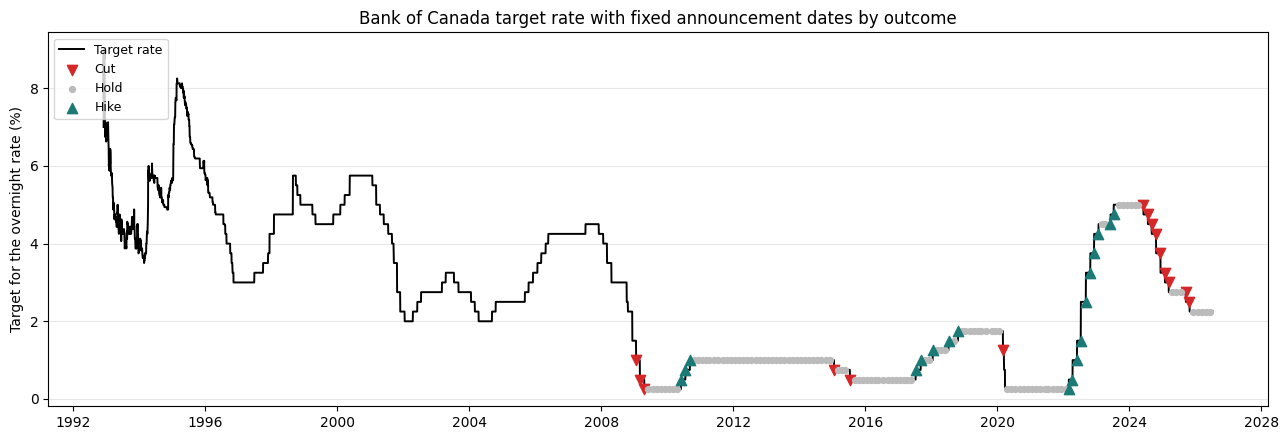

In [2]:
from boc_rate_decisions.plots import plot_policy_rate_with_decisions


fig, _ = plot_policy_rate_with_decisions(rate_df, direction_df, kind="direction")
plt.show()

---
## 3. Deriving the decision series

No published series encodes BoC *decisions* — the daily rate tells you the
level, but a flat line is ambiguous between "no meeting happened" and "a
meeting happened and the Bank held". That's why the meeting calendar is
committed as a curated YAML (`meeting_schedule.yaml`, built from the Bank's
own announcement archive) and joined against the daily rate:

- For each scheduled announcement date, compare the rate strictly *before*
  the date with the rate shortly *after* it.
- `−1` if the rate decreased (a cut of any size), `+1` if it increased, `0`
  if it held — that is `boc_rate_decision_direction`, the primary target.
  The binary `boc_rate_cut_event` series is a thin wrapper over the same
  comparison (`1.0` exactly where the direction is `−1`).
- The comparison uses a post-meeting lookahead window because the effective
  date of a change moved from same-day to next-day in 2021 — deriving from
  levels on both sides of the announcement is robust to that regime change.

`validate_schedule_against_rate_series` cross-checks the curated calendar:
every observed rate change must be attributable to a scheduled meeting or a
known unscheduled announcement (there is exactly one since 2009: the
emergency COVID cut of March 27, 2020, which is *excluded* from the task —
predicting emergency moves is a different problem).

In [3]:
from boc_rate_decisions.data import load_unscheduled_announcements, validate_schedule_against_rate_series


unattributed = validate_schedule_against_rate_series(
    rate_df, meeting_dates, unscheduled_dates=load_unscheduled_announcements()
)
print(f"Rate changes not attributable to a scheduled/known announcement: {len(unattributed)}")

# The last 10 resolved meetings, with the rate on each side of the announcement.
_LABELS = {-1.0: "CUT", 0.0: "HOLD", 1.0: "HIKE"}
recent = direction_df.tail(10).copy()
rate_by_date = rate_df.set_index("timestamp")["value"]
rows = []
for ts, direction in zip(recent["timestamp"], recent["value"]):
    before = float(rate_by_date[rate_by_date.index < ts].iloc[-1])
    after_window = rate_by_date[(rate_by_date.index >= ts) & (rate_by_date.index <= ts + pd.Timedelta(days=7))]
    after = float(after_window.iloc[-1]) if not after_window.empty else float("nan")
    rows.append(
        {
            "meeting": ts.date(),
            "rate_before": before,
            "rate_after": after,
            "outcome": _LABELS[float(direction)],
            "direction_value": int(direction),
        }
    )
print()
print(pd.DataFrame(rows).to_string(index=False))

Rate changes not attributable to a scheduled/known announcement: 0

   meeting  rate_before  rate_after outcome  direction_value
2025-04-16         2.75        2.75    HOLD                0
2025-06-04         2.75        2.75    HOLD                0
2025-07-30         2.75        2.75    HOLD                0
2025-09-17         2.75        2.50     CUT               -1
2025-10-29         2.50        2.25     CUT               -1
2025-12-10         2.25        2.25    HOLD                0
2026-01-28         2.25        2.25    HOLD                0
2026-03-18         2.25        2.25    HOLD                0
2026-04-29         2.25        2.25    HOLD                0
2026-06-10         2.25        2.25    HOLD                0


---
## 4. Class imbalance and the climatology floor

Holds are roughly three meetings in four since 2009; cuts and hikes split the
rest — and the per-year table below shows how lumpy those averages are: most
years are all-hold, while a handful of cycle years account for nearly all the
moves.

This sets the **floor baseline** for the experiment. The RPS of a forecast
over \(K\) ordered categories decomposes into \(K-1\) binary Brier scores of
the *cumulative* events — for cut < hold < hike:

\[ \mathrm{RPS} = \big(P(\text{cut}) - y_{\le\text{cut}}\big)^2 +
   \big(P(\text{cut}) + P(\text{hold}) - y_{\le\text{hold}}\big)^2, \]

where \(y_{\le k}\) indicates the realised outcome was at or below category
\(k\). Each binary term is minimised in expectation by the corresponding
cumulative base rate, so the constant *climatological distribution* — the
empirical cut/hold/hike frequencies — is the optimal conditions-blind
forecast. Any predictor that can't beat it has learned nothing from
conditions; that is exactly what `CategoricalFrequencyPredictor` implements
in notebook 02. (Set \(K = 2\) and the decomposition collapses to the
familiar binary Brier score \((p - y)^2\) — the identity the binary warm-up
verifies.)

      n_meetings  n_cut  n_hold  n_hike
year                                   
2009           8      3       5       0
2010           8      0       5       3
2011           8      0       8       0
2012           8      0       8       0
2013           8      0       8       0
2014           8      0       8       0
2015           8      2       6       0
2016           8      0       8       0
2017           8      0       6       2
2018           8      0       5       3
2019           8      0       8       0
2020           8      1       7       0
2021           8      0       8       0
2022           8      0       1       7
2023           8      0       5       3
2024           8      5       3       0
2025           8      4       4       0
2026           4      0       4       0

Overall base rates: cut 0.107, hold 0.764, hike 0.129
RPS of always predicting the climatology:  0.2077
RPS of always predicting uniform thirds:   0.3008
RPS of always predicting a certain hold:   0.

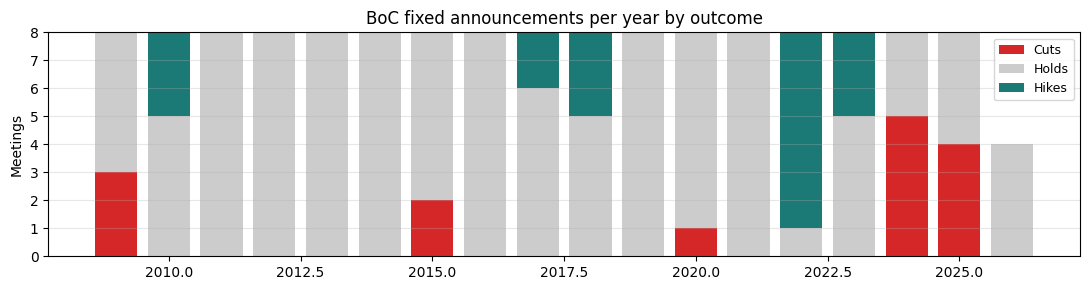

In [4]:
import numpy as np
from aieng.forecasting.evaluation import compute_rps
from boc_rate_decisions.analysis import yearly_outcome_table


yearly = yearly_outcome_table(direction_df, labels={-1.0: "cut", 0.0: "hold", 1.0: "hike"})
print(yearly.to_string())

base_rates = direction_df["value"].map({-1.0: "cut", 0.0: "hold", 1.0: "hike"}).value_counts(normalize=True)
climatology = [base_rates.get("cut", 0.0), base_rates.get("hold", 0.0), base_rates.get("hike", 0.0)]
outcome_idx = direction_df["value"].map({-1.0: 0, 0.0: 1, 1.0: 2}).tolist()
print(f"\nOverall base rates: cut {climatology[0]:.3f}, hold {climatology[1]:.3f}, hike {climatology[2]:.3f}")
print(f"RPS of always predicting the climatology:  {compute_rps([climatology] * len(outcome_idx), outcome_idx):.4f}")
uniform = [1 / 3, 1 / 3, 1 / 3]
print(f"RPS of always predicting uniform thirds:   {compute_rps([uniform] * len(outcome_idx), outcome_idx):.4f}")
always_hold = [0.0, 1.0, 0.0]
print(f"RPS of always predicting a certain hold:   {compute_rps([always_hold] * len(outcome_idx), outcome_idx):.4f}")

fig, ax = plt.subplots(figsize=(11, 3))
bottom = np.zeros(len(yearly))
for column, color, label in [
    ("n_cut", "#d62728", "Cuts"),
    ("n_hold", "#cccccc", "Holds"),
    ("n_hike", "#1b7a76", "Hikes"),
]:
    ax.bar(yearly.index, yearly[column], bottom=bottom, color=color, label=label)
    bottom += yearly[column].to_numpy()
ax.set_ylabel("Meetings")
ax.set_title("BoC fixed announcements per year by outcome")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Cutoff discipline at announcement dates

Forecast origins sit **four weeks before each announcement** (`as_of =
meeting − 28 days`, `horizons=[28]`, frequency `"D"`), so the forecast date
lands exactly on the meeting and the harness's cutoff enforcement excludes
everything after the origin. Scheduled meetings are never closer than 35
days apart, so the *previous* decision is always visible at the origin.
Because the meeting calendar is irregular, the backtest spec lists its
origins explicitly via `origin_dates` rather than deriving them from a
stride.

Each series carries a `released_at` column reflecting when the data was
*available*, not when it was *measured*. For daily market series (target
rate, bond yields) this is precise: next business day. For the monthly
series it is an **approximation** — `timestamp + 21 days` for StatCan CPI,
FRED's own approximate stamps for unemployment — and the approximation is
*optimistic*: StatCan actually publishes CPI for reference month *m* about
three weeks after the *end* of *m*, roughly 51 days after the month-start
timestamp.

This is why the predictors apply an extra month of conservative lag on
monthly covariates: they drop the newest reference month visible in the
context, which lands exactly on the month that was genuinely public at the
origin. The cell below shows both layers.

The cell below freezes the world four weeks before the June 2024 meeting —
the first cut of the 2024 easing cycle — and shows exactly what a predictor
was allowed to see.

In [5]:
# Freeze the information state 28 days before the 2024-06-05 announcement.
ctx = svc.context(as_of=datetime(2024, 5, 8))

visible_rate = ctx.get_series(TARGET_RATE_SERIES_ID)
visible_directions = ctx.get_series(DIRECTION_SERIES_ID)
visible_cpi = ctx.get_series(CPI_SERIES_ID)

print("As-of 2024-05-08 (announcement on 2024-06-05, 28 days out):")
print(
    f"  Last visible target rate:   {visible_rate['value'].iloc[-1]:.2f}%  on {visible_rate['timestamp'].iloc[-1].date()}"
)
print(
    f"  Last visible meeting:       {visible_directions['timestamp'].iloc[-1].date()}  "
    f"(outcome: {_LABELS[float(visible_directions['value'].iloc[-1])].lower()})"
)
print(
    f"  Last visible CPI month:     {visible_cpi['timestamp'].iloc[-1].date()}  "
    f"(approx. released_at {visible_cpi['released_at'].iloc[-1].date()})"
)
print(f"  CPI month predictors USE:   {visible_cpi['timestamp'].iloc[-2].date()}  (after the extra-month lag)")
print()
print("In reality, the April CPI print (released May 21, 2024) was NOT yet")
print("available on May 8 — the approximate released_at makes April look")
print("visible, and the predictors' extra-month lag corrects for exactly that.")
print()
print("Neither the 2024-06-05 meeting NOR anything after the origin is visible:")
print(f"  Meetings visible: {len(visible_directions)} of {len(direction_df)} resolved")
print()
print("What actually happened on 2024-06-05: the Bank cut 25bp to 4.75% —")
print("the first cut of the easing cycle. A predictor at this origin had the")
print("rate path, April's hold, and March CPI. Four weeks before the decision,")
print("markets had not yet fully converged on a June cut.")

As-of 2024-05-08 (announcement on 2024-06-05, 28 days out):
  Last visible target rate:   5.00%  on 2024-05-07
  Last visible meeting:       2024-04-10  (outcome: hold)
  Last visible CPI month:     2024-04-01  (approx. released_at 2024-04-22)
  CPI month predictors USE:   2024-03-01  (after the extra-month lag)

In reality, the April CPI print (released May 21, 2024) was NOT yet
available on May 8 — the approximate released_at makes April look
visible, and the predictors' extra-month lag corrects for exactly that.

Neither the 2024-06-05 meeting NOR anything after the origin is visible:
  Meetings visible: 123 of 140 resolved

What actually happened on 2024-06-05: the Bank cut 25bp to 4.75% —
the first cut of the easing cycle. A predictor at this origin had the
rate path, April's hold, and March CPI. Four weeks before the decision,
markets had not yet fully converged on a June cut.


---
## 6. Macro covariates

Three series the Bank itself watches, used by the logistic baseline and fed
to the LLM-based predictors:

- **2-year GoC yield vs the policy rate** — the bond market's implied policy
  path. The 2-year trading well *below* the overnight rate means markets are
  pricing cuts; well *above*, hikes. It is the single most informative
  pre-meeting signal, and it is naturally *directional*.
- **CPI inflation vs the 2% target** — the Bank's mandate. Sustained
  below-target inflation creates room to cut; above-target overshoots force
  hikes.
- **Unemployment momentum** — a rising unemployment rate pressures the Bank
  toward easing; a tight labour market supports tightening.

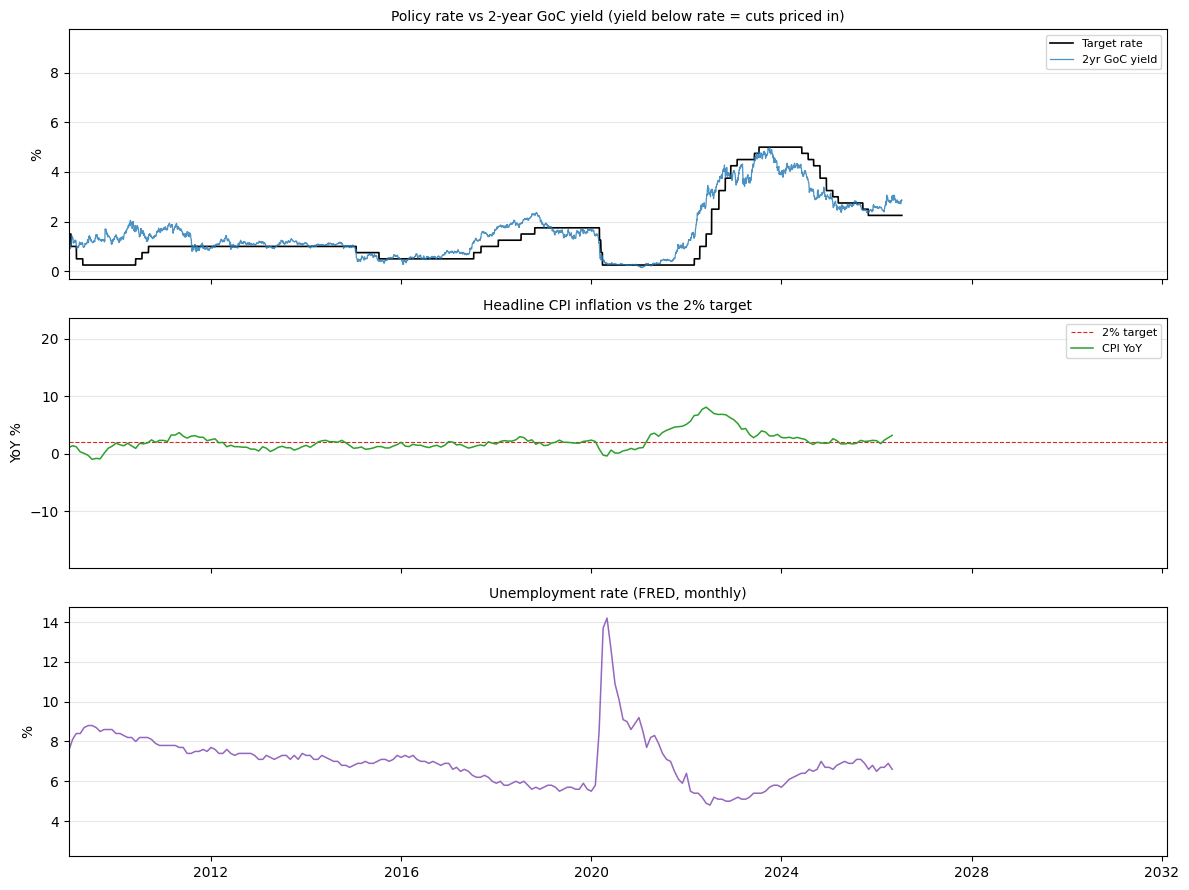

In [6]:
yield_df = svc.get_series(BOND_YIELD_2YR_SERIES_ID, as_of=_as_of)
cpi_df = svc.get_series(CPI_SERIES_ID, as_of=_as_of)
unemp_df = svc.get_series(UNEMPLOYMENT_SERIES_ID, as_of=_as_of)

cpi_yoy = cpi_df.set_index("timestamp")["value"].pct_change(12) * 100

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(rate_df["timestamp"], rate_df["value"], color="k", linewidth=1.2, label="Target rate")
axes[0].plot(yield_df["timestamp"], yield_df["value"], color="#1f77b4", linewidth=0.9, alpha=0.8, label="2yr GoC yield")
axes[0].set_ylabel("%")
axes[0].set_title("Policy rate vs 2-year GoC yield (yield below rate = cuts priced in)", fontsize=10)
axes[0].legend(fontsize=8)

axes[1].axhline(2.0, color="#d62728", linewidth=0.8, linestyle="--", label="2% target")
axes[1].plot(cpi_yoy.index, cpi_yoy.values, color="#2ca02c", linewidth=1.1, label="CPI YoY")
axes[1].set_ylabel("YoY %")
axes[1].set_title("Headline CPI inflation vs the 2% target", fontsize=10)
axes[1].legend(fontsize=8)

axes[2].plot(unemp_df["timestamp"], unemp_df["value"], color="#9467bd", linewidth=1.1)
axes[2].set_ylabel("%")
axes[2].set_title("Unemployment rate (FRED, monthly)", fontsize=10)

for ax in axes:
    ax.grid(axis="y", alpha=0.3)
    ax.set_xlim(pd.Timestamp("2009-01-01"), None)
plt.tight_layout()
plt.show()

---
## 7. What's next

`02_boc_rate_direction_experiment.ipynb` opens with a compact binary warm-up
(*cut vs no cut*, Brier-scored — the copy-paste reference for naturally
binary problems), then runs four predictors against the 3-way direction
task at the canonical 28-day lead — the climatology floor, a fit-at-origin
multinomial logistic regression on the covariates above, a
direct-elicitation categorical LLMP, and an agentic BoC analyst — and
compares them on RPS, one-vs-rest calibration, and the decision timeline.
It closes the loop on the lead-time question with a T−28 vs T−1
comparison: how much of each predictor's skill is anticipation, and how
much is reading the market on the eve of the decision?

Two components are deliberately deferred and have explicit seams in the
code: grounding the LLM-based predictors in the Bank's own communications
(press releases, Monetary Policy Reports), and an LLM evaluator that scores
*reasoning alignment* between the agent's rationale and the Bank's published
one. See the use-case `README.md` for the roadmap.